In [5]:
import tensorflow as tf # type: ignore
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
from dotenv import load_dotenv


### 1. Configurar o caminho e criar lista de imagens ###
load_dotenv()

img_dir = os.getenv("BASE_IMG_FOLDER")
img_dir = pathlib.Path(img_dir)
mask_dir = os.getenv("NUMPY_FOLDER")
mask_dir = pathlib.Path(mask_dir)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))
def get_file_number_mask(filepath):
    return int(os.path.basename(filepath).replace('.npy', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.npy'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number_mask)

print(f"Número de arquivos de imagem encontrados: {len(image_files)}")
print(f"Número de arquivos de máscara encontrados: {len(mask_files)}")

# Mostrar alguns exemplos de nomes de arquivos
print("Exemplos de nomes de arquivos de imagem:")
for i in image_files[:5]:
    print(i)
    
print("Exemplos de nomes de arquivos de máscara:")
for i in mask_files[:5]:
    print(i)

if len(image_files) != len(mask_files):
    raise ValueError("O número de imagens e máscaras não corresponde")

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)

2025-03-21 06:05:39.275521: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Número de arquivos de imagem encontrados: 5036
Número de arquivos de máscara encontrados: 5036
Exemplos de nomes de arquivos de imagem:
/media/renato/Data/PIBIC/FinalImage_v2/000.png
/media/renato/Data/PIBIC/FinalImage_v2/001.png
/media/renato/Data/PIBIC/FinalImage_v2/002.png
/media/renato/Data/PIBIC/FinalImage_v2/003.png
/media/renato/Data/PIBIC/FinalImage_v2/004.png
Exemplos de nomes de arquivos de máscara:
/media/renato/Data/PIBIC/NumpyFiles/000.npy
/media/renato/Data/PIBIC/NumpyFiles/001.npy
/media/renato/Data/PIBIC/NumpyFiles/002.npy
/media/renato/Data/PIBIC/NumpyFiles/003.npy
/media/renato/Data/PIBIC/NumpyFiles/004.npy
Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/renato/Data/PIBIC/NumpyFiles/000.npy
/media/renato/Data/PIBIC/NumpyFiles/001.npy
/media/renato/Data/PIBIC/NumpyFiles/002.npy
/media/renato/Data/PIBIC/NumpyFiles/003.npy
/media/renato/Data/PIBIC/NumpyFiles/004.npy


In [6]:
import numpy as np
# Linux
mask = np.load(r'/media/renato/Data/PIBIC/NumpyFiles/000.npy')

# Windows
# mask = np.load('C:\\Users\\Renato\\Documents\\PIBIC\\NumpyFiles\\000.npy')

In [7]:
mask.shape

(512, 512, 22)

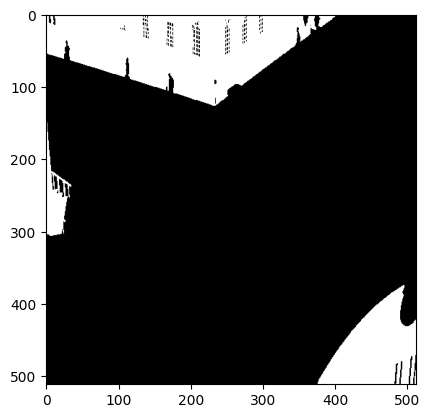

In [8]:
plt.imshow(mask[:,:,0], cmap='gray')

In [10]:
# Configurar o crescimento de memória da GPU de forma dinâmica usando o TensorFlow

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [13]:
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Carregar imagem RGB
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [512, 512])  # Redimensionar o tamanho
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar a imagem

        # Carregar máscara do arquivo numpy
        mask = np.load(mask_path.numpy().decode())  # Ler a máscara
        mask = tf.convert_to_tensor(mask, dtype=tf.float32)  # Converter como tensor

        # Normalizar máscara
        mask = mask / 255.0  # Converter valores de 0-255 a 0-1
        mask = tf.where(mask >= 0.3, 1.0, 0.0)  # Binarizar a máscara

        return img, mask

    except Exception as e:
        print(f"Erro ao processar imagem/máscara {image_path}, {mask_path}: {str(e)}")
        raise


## Função para aplicar aumento de dados considerando máscaras como arrays multicamadas
def augment_image_mask(image, mask):
    # Gere um valor aleatório comum para transformações
    flip_left_right = tf.random.uniform(shape=[]) > 0.5
    flip_up_down = tf.random.uniform(shape=[]) > 0.5
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)  # 0, 90, 180, 270 graus

    # Flip horizontal
    if flip_left_right:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip vertical
    if flip_up_down:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Aplicar rotação à imagem
    image = tf.image.rot90(image, k=k)

    # Aplique rotação à máscara em toda a sua dimensão
    mask = tf.image.rot90(mask, k=k)  # Agora giramos a máscara inteira de uma vez

    # Configurações adicionais de imagem
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, mask

# Converter listas de rotas em conjunto de dados do TensorFlow
def process_path(image_path, mask_path):
    img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
    img.set_shape((512, 512, 3))  # Defina o tamanho esperado da imagem
    mask.set_shape((512, 512, 22))  # Defina o tamanho esperado da máscara
    return img, mask

# Criar um conjunto de dados a partir de listas de imagens e máscaras
train_dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
train_dataset = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar Aumento de Dados
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

"""
O BATCH_SIZE determina quantas imagens e máscaras são processadas simultaneamente pela GPU/CPU durante o treinamento.
O BUFFER_SIZE determina quantos elementos são armazenados em memória para embaralhamento eficiente.
"""

### Configurar o conjunto de dados ###
# TF-CPU: Configuração original
# BUFFER_SIZE = 100
# BATCH_SIZE = 32
# TF-GPU: Configuração priorizando velocidade [Estouro de memória em treinamento]
# BUFFER_SIZE = 128
# BATCH_SIZE = 32
# TF-GPU: Configuração balanceada para performance e uso de memória [Estouro de memória em treinamento]
# BUFFER_SIZE = 64
# BATCH_SIZE = 16
# TF-GPU: Configuração para economia de memória [No limite máximo do meu computador]
BUFFER_SIZE = 32
BATCH_SIZE = 8
# TF-GPU: Configuração para economia de memória [?]
# BUFFER_SIZE = 16
# BATCH_SIZE = 4

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspecionar o conjunto de dados
for img, mask in train_dataset.take(1):
    print(f"Imagem em lote: {img.shape}")  # Esperado: (batch_size, 512, 512, 3)
    print(f"Máscara em lote: {mask.shape}")  # Esperado: (batch_size, 512, 512, 22)

Imagem em lote: (8, 512, 512, 3)
Máscara em lote: (8, 512, 512, 22)


In [14]:
mask[0]

<tf.Tensor: shape=(512, 512, 22), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0.

In [15]:
def unet_multilabel_improved(input_shape=(512, 512, 3), num_classes=22):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Encoder (Downsampling)
    def conv_block(x, filters, dropout_rate=0.1):
        x = tf.keras.layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        return x

    c1 = conv_block(inputs, 64)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = conv_block(p3, 512, dropout_rate=0.3)

    # Decoder (Upsampling)
    def upsample_block(x, skip_connection, filters):
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        x = tf.keras.layers.Conv2D(filters, (2, 2), activation='relu', padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Concatenate()([x, skip_connection])
        x = conv_block(x, filters)
        return x

    u5 = upsample_block(c4, c3, 256)
    u6 = upsample_block(u5, c2, 128)
    u7 = upsample_block(u6, c1, 64)

    # Output with sigmoid activation for multilabel binary masks
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(u7)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Create model
model = unet_multilabel_improved()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_5[0][0]  

 Total params: 7,711,766 (29.42 MB)

 Trainable params: 7,705,238 (29.39 MB)

 Non-trainable params: 6,528 (25.50 KB)

In [16]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_pred = tf.keras.backend.clip(y_pred, 1e-7, 1 - 1e-7)
        focal_loss = -alpha * y_true * tf.keras.backend.pow(1 - y_pred, gamma) * tf.keras.backend.log(y_pred)
        focal_loss -= (1 - alpha) * (1 - y_true) * tf.keras.backend.pow(y_pred, gamma) * tf.keras.backend.log(1 - y_pred)
        return tf.keras.backend.mean(focal_loss)
    return loss

In [17]:
## Obter o número total de amostras no conjunto de dados sem lote prévio
dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
dataset_size = tf.data.experimental.cardinality(dataset).numpy()

# Definir proporções para treinar, validar e testar
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

# Mesclar o conjunto de dados antes de dividir
shuffled_dataset = dataset.shuffle(BUFFER_SIZE)
shuffled_dataset = shuffled_dataset.shuffle(BUFFER_SIZE)

# Divida o conjunto de dados ANTES de aplicar o lote para evitar o problema de lote duplo
train_dataset = shuffled_dataset.take(train_size)
remaining_dataset = shuffled_dataset.skip(train_size)
val_dataset = remaining_dataset.take(val_size)
test_dataset = remaining_dataset.skip(val_size)

# Aplicar aumento de dados apenas ao conjunto de treinamento
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar lote após divisão
# train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(1)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(1)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(1)

"""
O valor de prefetch igual a 1 significa que enquanto o modelo processa um batch, 
o pipeline carrega apenas o próximo batch, minimizando o uso de memória.
Isto deve resolver o problema de alocação de memória excessiva.
"""

# Confirmar os tamanhos do conjunto
print(f'Tamanho do conjunto de dados de treinamento: {train_size}')
print(f'Tamanho do conjunto de dados de validação: {val_size}')
print(f'Tamanho do conjunto de dados de avaliação: {test_size}')


Tamanho do conjunto de dados de treinamento: 4028
Tamanho do conjunto de dados de validação: 503
Tamanho do conjunto de dados de avaliação: 505


In [18]:
import gc

# Limpar memória antes do treinamento
gc.collect()
tf.keras.backend.clear_session()

In [19]:
# Callbacks para melhorar o treinamento
callbacks = [
    # Early stopping para evitar Overfitting (sobreajuste)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # Permitir mais épocas antes de se deter se não houver melhor
        restore_best_weights=True,
        verbose=1
    ),

    # Salvar o melhor modelo baseado na menor perda de validação
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_focal.keras',
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    ),

    # Reduza a taxa de aprendizagem se a perda de validação persistir
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # Reduza a tarefa de aprendizagem para a metade se não for melhor
        patience=5,  # Esperar 5 épocas sem melhorar antes de reduzir
        min_lr=1e-6,  # Limite inferior para a tarefa de aprendizagem
        verbose=1
    ),

    # Registrador de métricas no TensorBoard
    tf.keras.callbacks.TensorBoard(
        log_dir='logs_focal',
        histogram_freq=1,
        write_graph=True,
        write_images=True
    )
]

# Compilar o modelo com perda focal e especificações específicas
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Taxa de aprendizagem inicial
    loss=focal_loss(),
    metrics=[
        'accuracy', 
        tf.keras.metrics.MeanIoU(num_classes=22), # Número de classes
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall()
    ]
)

# Definir a estratégia de treinamento em fases (ajuste fino)
EPOCHS_PHASE_1 = 75  # Treinamento inicial
EPOCHS_PHASE_2 = 25  # Ajuste fino

print("Treinamento: Fase 1 - Aprendizagem inicial")
history_1 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_1,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

# Recompilar o modelo para a fase de ajuste fino com taxa de aprendizagem reduzida
print("Recompilando modelo para ajuste fino...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Taxa reduzida para ajuste fino
    loss=focal_loss(),
    metrics=[
        'accuracy', 
        tf.keras.metrics.MeanIoU(num_classes=22),
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall()
    ]
)

print("Treinamento: Fase 2 - Ajuste fino com taxa de aprendizagem reduzida")
history_2 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE_2,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)


Treinamento: Fase 1 - Aprendizagem inicial
Epoch 1/75


I0000 00:00:1742537257.120848   34045 service.cc:146] XLA service 0x70b3c4721130 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742537257.120903   34045 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-03-21 06:07:37.624751: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742537262.911754   34045 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


343/504 ━━━━━━━━━━━━━━━━━━━━ 3:10 1s/step - accuracy: 0.1875 - loss: 0.1616 - mean_io_u: 0.4787 - precision: 0.0606 - recall: 0.6794

KeyboardInterrupt: 

In [ ]:
# Visualização da evolução do treinamento
import matplotlib.pyplot as plt

def plot_training_metrics(history_1, history_2):
    # Vamos imprimir as chaves disponíveis para diagnóstico
    print("Chaves disponíveis em history_1:", list(history_1.history.keys()))
    print("Chaves disponíveis em history_2:", list(history_2.history.keys()))
    
    # Método mais seguro: crie o dicionário combined_history apenas com as chaves que existem
    combined_history = {}
    
    # Adicionar perda e perda de validação (essas sempre existem)
    if 'loss' in history_1.history and 'loss' in history_2.history:
        combined_history['loss'] = history_1.history['loss'] + history_2.history['loss']
    if 'val_loss' in history_1.history and 'val_loss' in history_2.history:
        combined_history['val_loss'] = history_1.history['val_loss'] + history_2.history['val_loss']
    
    # Adicionar accuracy
    if 'accuracy' in history_1.history and 'accuracy' in history_2.history:
        combined_history['accuracy'] = history_1.history['accuracy'] + history_2.history['accuracy']
    if 'val_accuracy' in history_1.history and 'val_accuracy' in history_2.history:
        combined_history['val_accuracy'] = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
    
    # Tentar diferentes variações do nome precision
    precision_keys = ['precision', 'precision_1', 'precision_mean']
    for key in precision_keys:
        if key in history_1.history and key in history_2.history:
            combined_history['precision'] = history_1.history[key] + history_2.history[key]
            break
    
    val_precision_keys = ['val_precision', 'val_precision_1', 'val_precision_mean']
    for key in val_precision_keys:
        if key in history_1.history and key in history_2.history:
            combined_history['val_precision'] = history_1.history[key] + history_2.history[key]
            break
    
    # Tentar diferentes variações do nome recall
    recall_keys = ['recall', 'recall_1', 'recall_mean']
    for key in recall_keys:
        if key in history_1.history and key in history_2.history:
            combined_history['recall'] = history_1.history[key] + history_2.history[key]
            break
    
    val_recall_keys = ['val_recall', 'val_recall_1', 'val_recall_mean']
    for key in val_recall_keys:
        if key in history_1.history and key in history_2.history:
            combined_history['val_recall'] = history_1.history[key] + history_2.history[key]
            break

    plt.figure(figsize=(15, 5))
    
    # Perda - sempre presente
    plt.subplot(1, 3, 1)
    plt.plot(combined_history.get('loss', []), label='Perda de treinamento')
    plt.plot(combined_history.get('val_loss', []), label='Perda de validação')
    plt.title('Evolução da perda')
    plt.legend()

    # Precisão 
    plt.subplot(1, 3, 2)
    plt.plot(combined_history.get('accuracy', []), label='Precisão de treinamento')
    plt.plot(combined_history.get('val_accuracy', []), label='Precisão de validação')
    plt.title('Evolução da Precisão')
    plt.legend()

    # Recall - se disponível
    if 'recall' in combined_history or 'val_recall' in combined_history:
        plt.subplot(1, 3, 3)
        plt.plot(combined_history.get('recall', []), label='Recall de treinamento')
        plt.plot(combined_history.get('val_recall', []), label='Recall de validação')
        plt.title('Evolução do Recall')
        plt.legend()
    
    plt.tight_layout()
    plt.show()


plot_training_metrics(history_1, history_2)

In [ ]:
import matplotlib.pyplot as plt

def visualize_multilabel_predictions(model, dataset):
    for img, mask in dataset.take(1):
        pred_mask = model.predict(tf.expand_dims(img[0], axis=0))[0]

        plt.figure(figsize=(10, 5))

        # Imagem original
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].numpy())
        plt.title("Imagem Original")

        # Ver classe 0 real e prevista
        plt.subplot(1, 3, 2)
        plt.imshow(mask[0][:, :, 0], cmap='gray')
        plt.title("Máscara Real (Classe 0)")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[:, :, 0], cmap='gray')
        plt.title("Máscara Prevista (Classe 0)")

        plt.show()
        break

visualize_multilabel_predictions(model, train_dataset)